In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [2]:
X, y = make_moons(100, noise=0.25,random_state=2)

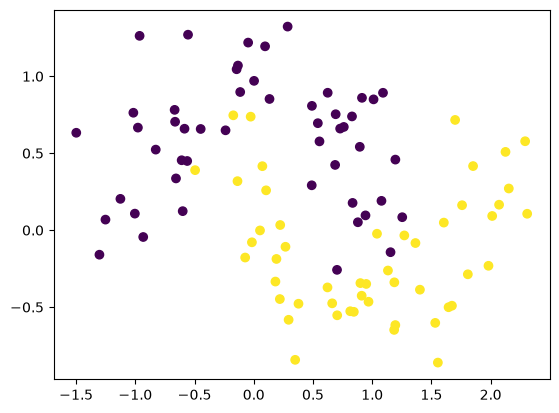

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [13]:
# creating model

model1 = Sequential()

model1.add(Dense(128,input_dim=2, activation="relu"))
model1.add(Dense(128, activation="relu"))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
adam = Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history1 = model1.fit(X, y, epochs=2000, validation_split = 0.2,verbose=1)

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.7000 - loss: 0.6194 - val_accuracy: 0.9000 - val_loss: 0.3954
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8125 - loss: 0.4387 - val_accuracy: 0.9000 - val_loss: 0.2286
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8500 - loss: 0.3821 - val_accuracy: 0.9000 - val_loss: 0.2416
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8375 - loss: 0.3957 - val_accuracy: 0.9000 - val_loss: 0.2528
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8375 - loss: 0.3412 - val_accuracy: 0.8500 - val_loss: 0.1989
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8375 - loss: 0.4025 - val_accuracy: 0.9000 - val_loss: 0.2025
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8500 - loss: 0.3644 - val_accuracy: 0.9000 - val_loss: 0.2335
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8500 - loss: 0.3423 - val_accuracy: 0.9000 - v

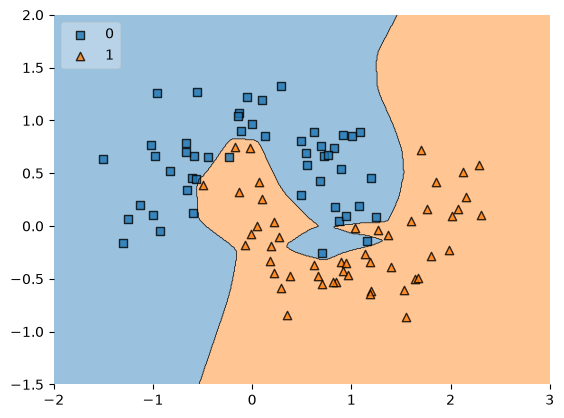

In [15]:
class MyModel:
    def predict(self, X):
        pred = model1.predict(X, verbose=0)
        return (pred >= 0.5).astype(int).ravel()


clf = MyModel()

plot_decision_regions(
    X,
    y.astype(int),
    clf=clf,
    legend=2
)

plt.xlim(-2, 3)
plt.ylim(-1.5, 2)
plt.show()

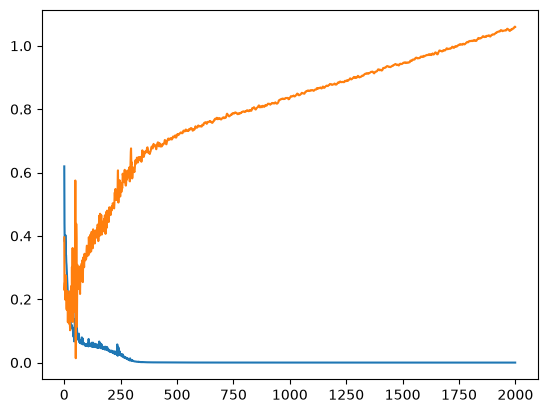

In [16]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

In [ ]:
# Modularization 

In [18]:
model2 = Sequential()

model2.add(Dense(128,input_dim=2, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.03)))
model2.add(Dense(128, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.03)))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model2.fit(X, y, epochs=2000, validation_split = 0.2,verbose=1)

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.5750 - loss: 4.1331 - val_accuracy: 0.8500 - val_loss: 2.7649
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8125 - loss: 2.4432 - val_accuracy: 0.9000 - val_loss: 1.5876
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8000 - loss: 1.4363 - val_accuracy: 0.9000 - val_loss: 0.9492
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8125 - loss: 0.9144 - val_accuracy: 0.9000 - val_loss: 0.6526
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8125 - loss: 0.7053 - val_accuracy: 0.9000 - val_loss: 0.5448
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8125 - loss: 0.6497 - val_accuracy: 0.9000 - val_loss: 0.5395
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8375 - loss: 0.6524 - val_accuracy: 0.9000 - val_loss: 0.5643
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8500 - loss: 0.6474 - val_accuracy: 0.9000 - v

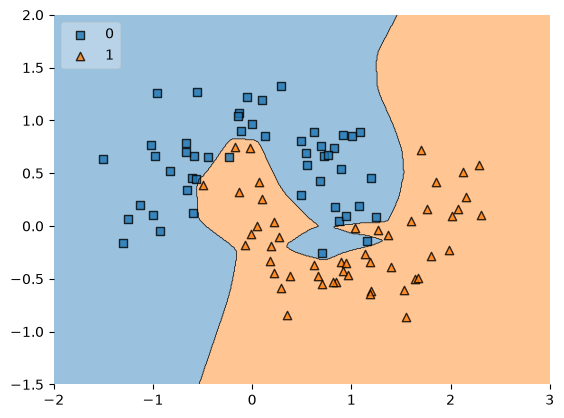

In [20]:

class MyModel:
    def predict(self, X):
        pred = model1.predict(X, verbose=0)
        return (pred >= 0.5).astype(int).ravel()


clf = MyModel()

plot_decision_regions(
    X,
    y.astype(int),
    clf=clf,
    legend=2
)

plt.xlim(-2, 3)
plt.ylim(-1.5, 2)
plt.show()

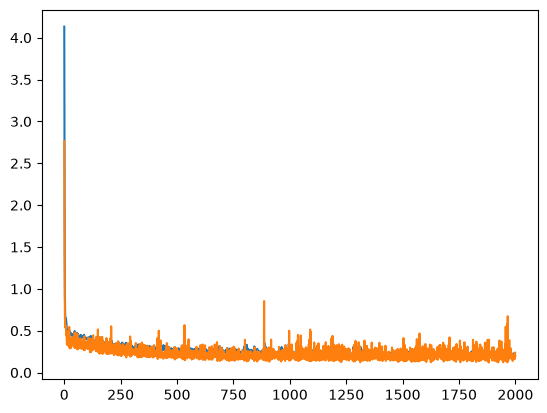

In [21]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [22]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

<Axes: >

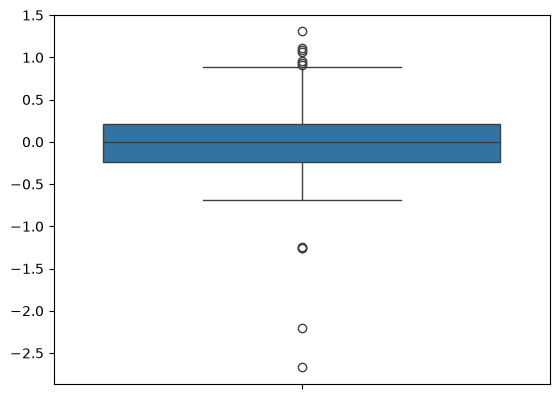

In [23]:
sns.boxplot(model1_weight_layer1)


<Axes: >

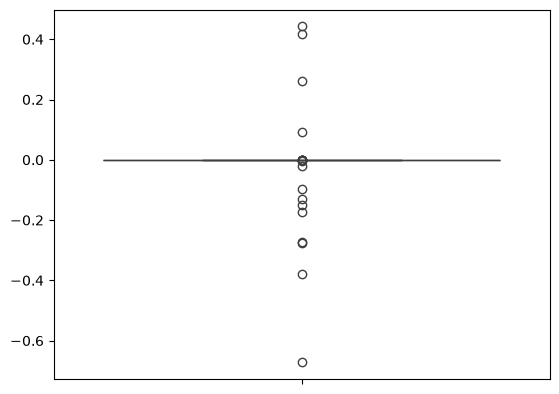

In [24]:
sns.boxplot(model2_weight_layer1)

In [25]:
model1_weight_layer1.min()

np.float32(-2.6697474)

In [26]:
model2_weight_layer1.min()

np.float32(-0.67208254)

C:\Users\Shubham Chauhan\AppData\Local\Temp\ipykernel_9308\2224180084.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model1_weight_layer1)
C:\Users\Shubham Chauhan\AppData\Local\Temp\ipykernel_9308\2224180084.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model2_weight_layer1)


<Axes: ylabel='Density'>

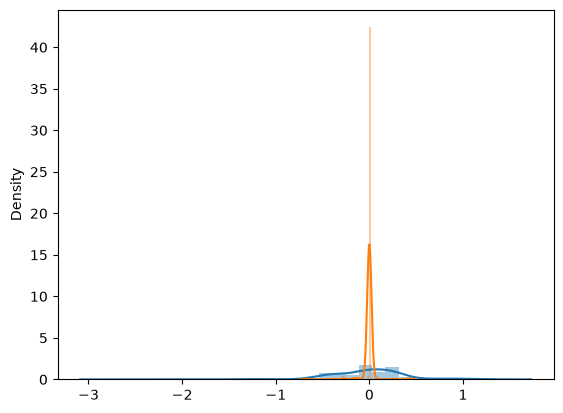

In [27]:
sns.distplot(model1_weight_layer1)
sns.distplot(model2_weight_layer1)

In [28]:
model1.get_weights()[0].reshape(256)

array([ 2.16531962e-01, -1.63185164e-01, -4.28176373e-01, -3.34376603e-01,
        2.12816462e-01, -3.96791875e-01,  1.28888428e-01,  1.80293903e-01,
        2.68580973e-01,  8.48045647e-02, -5.27056515e-01, -3.61875951e-01,
        1.88640103e-01, -2.07625255e-01,  2.43033171e-01,  1.55892164e-01,
        1.61168903e-01,  3.96753043e-01, -5.70435643e-01,  3.14266473e-01,
       -3.34767640e-01, -3.49165767e-01,  1.19552441e-01, -4.49312836e-01,
        2.61540502e-01, -4.20003504e-01, -3.64227861e-01,  1.64198522e-02,
        4.11029547e-01, -5.56732297e-01, -2.25912809e-01,  2.17129081e-01,
        2.19881713e-01,  2.32801542e-01, -2.86647156e-02, -1.69588655e-01,
       -2.44913865e-02,  2.71346420e-01, -3.52987468e-01,  2.65451312e-01,
        1.38404027e-01,  9.25929621e-02,  2.91622013e-01,  1.84995625e-02,
       -4.26132493e-02, -8.42115134e-02,  5.03791906e-02,  3.86286110e-01,
       -3.98642868e-01,  2.12187860e-02,  2.75811017e-01,  2.94416755e-01,
        7.17981160e-02,  